In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
import matplotlib.ticker as ticker # Import ticker

In [2]:
def plot_emission_spectrum(
    data_df,
    nm_col=None,
    intensity_col=None,
    prominence_percentage=0.12,
    x_min=400,
    x_max=750,
    fig_size=(15, 3),            # Bumped up slightly to fit labels nicely
    min_brightness=0.1,
    save_path=None,
    min_needle_max_width_nm=0.3, # Controls your standard line thickness
    max_needle_max_width_nm=0.8,
    glow_width_multiplier=1.5,
    glow_alpha=0.25,
    dpi=600,
    mode='dark',
    peak_label_y_position=0.85,  # Height boundary for text tags
    max_needle_y_scale=0.75,     # Height boundary for color bars
    peak_wavelengths=None,
):
    # 1. Resolve column aliases
    if nm_col is None:
        nm_col = next((c for c in data_df.columns if str(c).lower() in 
                       ["nm", "wavelength", "wavelength_nm", "lambda", "lambda_nm", "wl", "wl_nm"]), None)
    if intensity_col is None:
        intensity_col = next((c for c in data_df.columns if str(c).lower() in 
                        ["grey val", "grey value", "gray val", "grayscale", "intensity", "signal", "counts", "value", "int", "rel. int.", "grey"]), None)

    # 2. Extract and sanitize raw text records
    df_plot_data = data_df.copy()
    df_plot_data['_clean_nm'] = df_plot_data[nm_col].astype(str).str.replace('*', '', regex=False).str.replace('bl', '', regex=False).str.strip()
    df_plot_data['_clean_int'] = df_plot_data[intensity_col].astype(str).str.replace('*', '', regex=False).str.replace('bl', '', regex=False).str.replace('?', '', regex=False).str.strip()
    
    df_plot_data['_clean_nm'] = pd.to_numeric(df_plot_data['_clean_nm'], errors='coerce')

    def extract_numeric_intensity(val_str):
        if not val_str or val_str.lower() == 'nan': return 0.0
        nums = ''.join(c for c in str(val_str) if c.isdigit() or c == '.')
        return float(nums) if nums else 0.0

    df_plot_data['_raw_intensity'] = df_plot_data['_clean_int'].apply(extract_numeric_intensity)
    
    # Process boundaries
    df_plot_data = df_plot_data.dropna(subset=['_clean_nm', '_raw_intensity']).copy()
    df_plot_data = df_plot_data[(df_plot_data['_clean_nm'] >= x_min) & (df_plot_data['_clean_nm'] <= x_max)].copy()
    
    # Compress overlapping entries
    df_plot_data['_rounded_nm'] = df_plot_data['_clean_nm'].round(4)
    aggregated_df = df_plot_data.groupby('_rounded_nm', as_index=False).agg({'_raw_intensity': 'sum'})
    aggregated_df = aggregated_df.sort_values(by='_rounded_nm').reset_index(drop=True)
    
    nm_col = '_rounded_nm'
    intensity_col = '_raw_intensity'

    # Normalization matrix
    min_intensity_val = aggregated_df[intensity_col].min()
    max_intensity_val = aggregated_df[intensity_col].max()
    intensity_range = max_intensity_val - min_intensity_val
    if intensity_range == 0 or np.isnan(intensity_range):
        aggregated_df['Normalized_Intensity'] = 1.0
    else:
        aggregated_df['Normalized_Intensity'] = (aggregated_df[intensity_col] - min_intensity_val) / intensity_range

    # --- REPLACED PEAK DETECTION SECTION ---
    if peak_wavelengths is not None:
        nm_vals = aggregated_df[nm_col].values
        peaks = []
        for pw in peak_wavelengths:
            try: pv = float(pw)
            except Exception: continue
            idx = int(np.argmin(np.abs(nm_vals - pv)))
            peaks.append(idx)
        peaks = sorted(set(peaks))
    else:
        # Instead of find_peaks, we use a rolling local maximum window.
        # This catches sharp shoulders and independent multi-lines in a tight space.
        peaks = []
        window_radius = 2  # Checks 2 points to the left and 2 points to the right
        
        # Calculate a low floor threshold based on your prominence percentage
        intensity_floor = aggregated_df['Normalized_Intensity'].max() * (prominence_percentage * 0.2)
        
        for i in range(window_radius, len(aggregated_df) - window_radius):
            current_int = aggregated_df.iloc[i]['Normalized_Intensity']
            
            # Skip noise lines that are too faint to matter globally
            if current_int < intensity_floor:
                continue
                
            # Check if this data point is the highest in its immediate neighborhood
            neighborhood = aggregated_df.iloc[i - window_radius : i + window_radius + 1]['Normalized_Intensity']
            if current_int == neighborhood.max():
                peaks.append(i)


    # 3. Canvas setup
    fig, ax = plt.subplots(figsize=fig_size, dpi=dpi)
    text_color = 'white' if mode == 'dark' else 'black'

    fig.patch.set_facecolor('black' if mode == 'dark' else 'white')
    ax.set_facecolor('black')
    ax.yaxis.set_visible(False)
    ax.set_xlabel('Wavelength (nm)', color=text_color, fontweight='bold', labelpad=10)

    # Clean, modern axis rulers (GRID REMOVED)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(50))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(10))
    ax.tick_params(axis='x', which='major', colors=text_color, labelsize=10)
    ax.tick_params(axis='x', which='minor', colors=text_color, length=4, width=0.5)
    
    # CRITICAL CHANGE: Force grid lines to remain turned off completely
    ax.grid(False)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, 1)

    def wavelength_to_rgb(wavelength):
        """
        Converts a wavelength (380nm - 780nm) to a perceptually boosted sRGB triplet.
        Applies aggressive saturation and custom gamma curves to maximize visual vibrancy,
        preventing monitor color dilution (dullness) without clipping features.
        """
        wl = float(wavelength)
        
        # 1. Base Region Color Mapping
        if 380 <= wl < 440:
            R = -(wl - 440) / (440 - 380)
            G = 0.0
            B = 1.0
        elif 440 <= wl < 490:
            R = 0.0
            G = (wl - 440) / (490 - 440)
            B = 1.0
        elif 490 <= wl < 510:
            R = 0.0
            G = 1.0
            B = -(wl - 510) / (510 - 490)
        elif 510 <= wl < 580:
            R = (wl - 510) / (580 - 510)
            G = 1.0
            B = 0.0
        elif 580 <= wl < 645:
            R = 1.0
            G = -(wl - 645) / (645 - 580)
            B = 0.0
        elif 645 <= wl <= 780:
            R = 1.0
            G = 0.0
            B = 0.0
        else:
            return 0.0, 0.0, 0.0

        # 2. Human Eye Boundary Attenuation
        if 380 <= wl < 420:
            factor = 0.3 + 0.7 * (wl - 380) / (420 - 380)
        elif 420 <= wl < 701:
            factor = 1.0
        elif 701 <= wl <= 780:
            factor = 0.3 + 0.7 * (780 - wl) / (780 - 701)
        else:
            factor = 0.0

        # Apply boundary factor
        R *= factor
        G *= factor
        B *= factor

        # 3. UNIVERSAL VIBRANCY BOOST (The Saturation Matrix)
        # Standard equations let channels bleed, adding 'white' to mixed colors (like cyan/yellow).
        # This non-linear boost deepens pure hues and eliminates pasty/milky undertones.
        vibrancy_power = 1.3  # Increase to 1.5 for extreme pop, drop to 1.1 for softer hues
        
        if R > 0: R = R ** vibrancy_power
        if G > 0: G = G ** vibrancy_power
        if B > 0: B = B ** vibrancy_power

        # 4. Pure Primary Enforcement
        # If a color is mostly blue or mostly red, we suppress the trace leakage of other channels
        # to keep the lines crisp and punchy, preventing neon lines from looking pastel.
        max_channel = max(R, G, B)
        if max_channel > 0:
            # Dynamically push the dominant channel closer to maximum saturation limits
            scale = max_channel / (max_channel ** 0.85)
            R = min(1.0, R * scale)
            G = min(1.0, G * scale)
            B = min(1.0, B * scale)

        return R, G, B


    # 4. Rendering Loop
    for idx, row in aggregated_df.iterrows():
        nm_val = float(row[nm_col])
        norm_int = float(row['Normalized_Intensity'])
        base_rgb = wavelength_to_rgb(nm_val)
        is_peak = idx in peaks
        
        if is_peak:
            final_scale = min_brightness + (1 - min_brightness) * (norm_int ** 0.8)
            final_scale = min(1.0, final_scale * 1.4)
            z_order = 3
        else:
            final_scale = (min_brightness + (1 - min_brightness) * norm_int) * 0.4
            z_order = 1

        colored_rgb = (base_rgb[0] * final_scale, base_rgb[1] * final_scale, base_rgb[2] * final_scale)

        # CRITICAL CHANGE: Force heights to be perfectly straight vertical bars (Uniform constant width)
        y_height = max_needle_y_scale if is_peak else max_needle_y_scale * 0.7
        y_steps = np.array([0, y_height])
        
        # Keep width absolute and uniform from zero to peak height (No power taper)
        widths = min_needle_max_width_nm * np.ones_like(y_steps)
        x_left = nm_val - widths / 2
        x_right = nm_val + widths / 2
        
        # Render the uniform line bodies
        ax.fill_betweenx(y_steps, x_left, x_right, facecolor=colored_rgb, alpha=1.0 if is_peak else 0.3, edgecolor='none', zorder=z_order)

        # Render neon glow layer around peaks
        if is_peak and glow_width_multiplier > 1.0:
            glow_widths = widths * glow_width_multiplier
            g_left = nm_val - glow_widths / 2
            g_right = nm_val + glow_widths / 2
            ax.fill_betweenx(y_steps, g_left, g_right, facecolor=colored_rgb, alpha=glow_alpha, edgecolor='none', zorder=2)

        # NEW IMPLEMENTATION: Dynamic Labeling Engine for Peaks
        if is_peak:
            # Place text anchor exactly above the bar's tip boundary coordinate
            ax.text(
                x=nm_val,
                y=peak_label_y_position,
                s=f"{nm_val:.1f}",     # Round string label to 1 decimal place (e.g. "615.6")
                color=text_color,
                fontsize=8,
                rotation=90,          # Rotate 90 degrees to fit tight doublets/triplets cleanly
                ha='center',          # Horizontal center alignment
                va='bottom',          # Vertical bottom alignment
                fontweight='bold',
                zorder=4
            )

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, facecolor=fig.get_facecolor(), edgecolor='none', dpi=dpi)
    
    return fig, ax

--> Successfully Auto-Detected Columns:
    Wavelength Column: 'Observed Wavelength Air (nm)'
    Intensity Column:  'Rel. Int.'



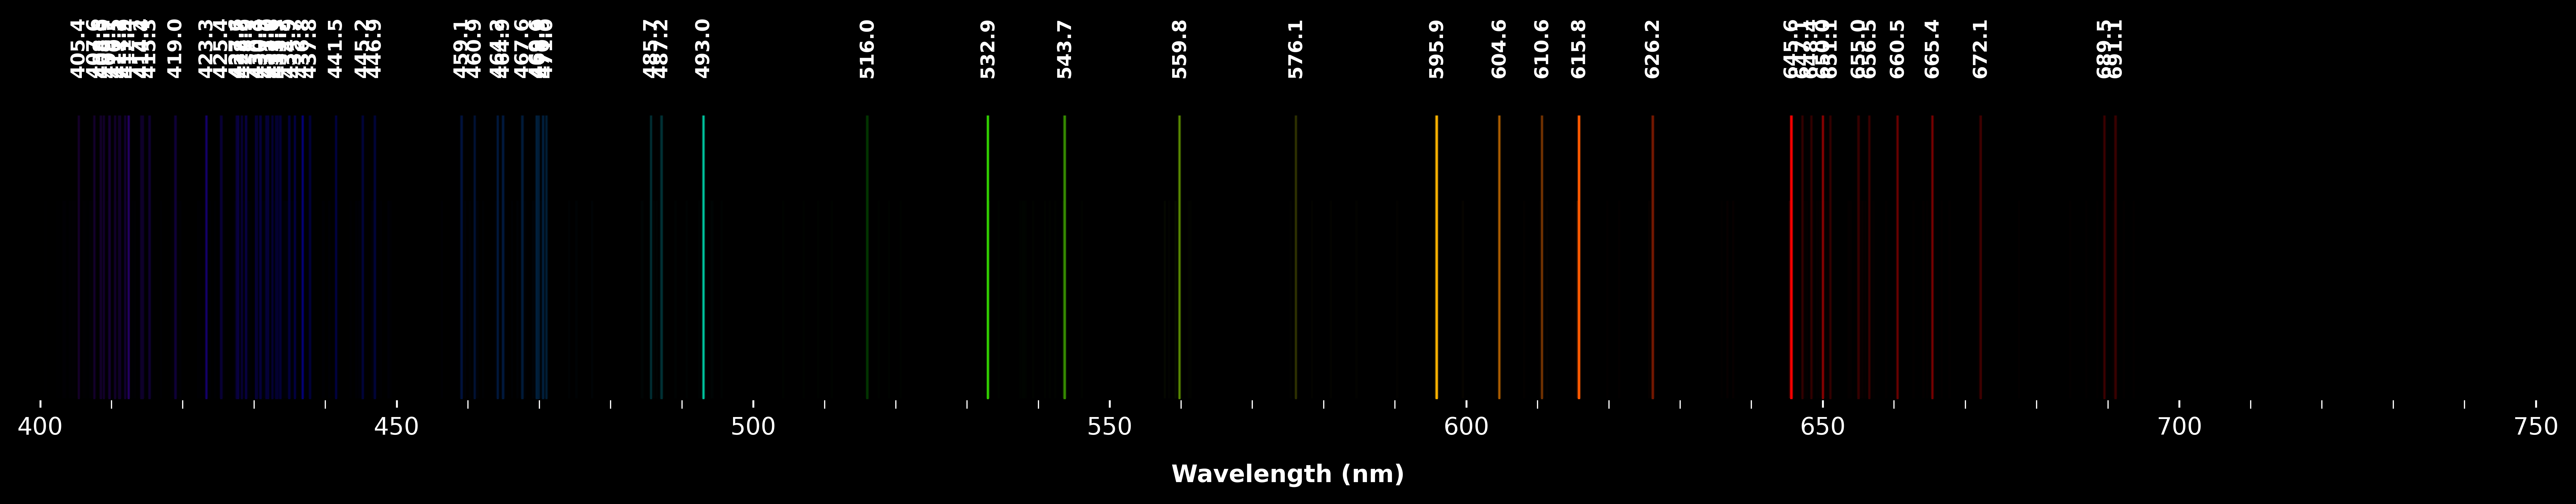

In [3]:
# --- RUNTIME CONFIGURATION ---
EXCEL_FILE_PATH = "oxygen nist 2.xlsx" 

# Setup your desired visual rendering window
MIN_WAVELENGTH = 400.0   # x_min
MAX_WAVELENGTH = 750.0   # x_max
LINE_THICKNESS = 0.3     # min_needle_max_width_nm

# 1. Load the Excel data file into memory
df = pd.read_excel(EXCEL_FILE_PATH)

# 2. Smart Keyword Matcher for Column Headers
WAVELENGTH_KEYWORDS = ['wavelength', 'wave', 'lambda', 'nm', 'obs']
INTENSITY_KEYWORDS = ['intensity', 'int.', 'int', 'rel', 'rel.', 'aki', 'grey val', 'counts']

detected_nm_col = None
detected_intensity_col = None

for col in df.columns:
    col_lower = str(col).lower()
    if any(kw in col_lower for kw in WAVELENGTH_KEYWORDS):
        detected_nm_col = col
    elif any(kw in col_lower for kw in INTENSITY_KEYWORDS):
        detected_intensity_col = col

# Safety confirmation check before calling the rendering loop
if not detected_nm_col or not detected_intensity_col:
    raise KeyError(
        f"Could not automatically detect matching columns.\n"
        f"Available columns in sheet: {list(df.columns)}"
    )

print(f"--> Successfully Auto-Detected Columns:")
print(f"    Wavelength Column: '{detected_nm_col}'")
print(f"    Intensity Column:  '{detected_intensity_col}'\n")

# 3. Call your integrated function using the dynamic parameters
fig, ax = plot_emission_spectrum(
    data_df=df,
    nm_col=detected_nm_col,
    intensity_col=detected_intensity_col,
    prominence_percentage=0.08,             # Lowered slightly to capture close multiplets better
    x_min=MIN_WAVELENGTH,
    x_max=MAX_WAVELENGTH,
    min_needle_max_width_nm=LINE_THICKNESS,  # Sets base line width
    max_needle_max_width_nm=0.8,             # Sets maximum flare width
    glow_width_multiplier=1.8,               # Controls your neon aura thickness
    glow_alpha=0.20,                         # Controls ambient glow visibility
    mode='dark',                             # Dark background mode
)

# 4. Display the live vector asset directly inside your Notebook workspace
plt.show()